In [14]:
import pandas as pd

# Load the dataset
file_path = 'clean_kaplan_data.csv'
data = pd.read_csv(file_path)

# EDA for numeric columns
def numeric_eda(data):
    numeric_cols = data.select_dtypes(include=['number'])
    numeric_eda = pd.DataFrame({
        'Column': numeric_cols.columns,
        'Mean': numeric_cols.mean(),
        'Median': numeric_cols.median(),
        'Std Dev': numeric_cols.std(),
        'Min': numeric_cols.min(),
        'Max': numeric_cols.max(),
        'Missing Values': numeric_cols.isna().sum(),
        'Unique Values': numeric_cols.nunique()
    })
    return numeric_eda

# EDA for categorical columns
def categorical_eda(data):
    categorical_cols = data.select_dtypes(include=['object', 'category'])
    categorical_eda = pd.DataFrame({
        'Column': categorical_cols.columns,
        'Missing Values': categorical_cols.isna().sum(),
        'Unique Values': categorical_cols.nunique(),
        'Top Category': categorical_cols.apply(lambda col: col.value_counts().idxmax()),
        'Frequency of Top Category': categorical_cols.apply(lambda col: col.value_counts().max())
    })
    return categorical_eda

# Perform EDA
numeric_summary = numeric_eda(data)
categorical_summary = categorical_eda(data)

display(data.isnull().sum())
display(numeric_summary)
display(categorical_summary)

name              0
even_month       11
value_fp          0
value_sp          0
value_ap          0
bid_fp            0
bid_sp            0
bid_ap            0
birthday          1
matched_info      2
reason          179
dtype: int64

,Column,Mean,Median,Std Dev,Min,Max,Missing Values,Unique Values
value_fp,value_fp,14.538043,14.0,8.562127,1.0,36.0,0,32
value_sp,value_sp,16.902174,17.0,8.777841,1.0,38.0,0,32
value_ap,value_ap,15.110870,14.0,9.086241,1.0,39.0,0,34
bid_fp,bid_fp,10.128424,10.0,7.570986,0.0,38.0,0,44
bid_sp,bid_sp,68.165054,11.6,736.255815,0.0,10000.0,0,52
bid_ap,bid_ap,7.643098,4.0,9.996916,0.0,60.0,0,42


,Column,Missing Values,Unique Values,Top Category,Frequency of Top Category
name,name,0,158,James,6
even_month,even_month,11,4,no,93
birthday,birthday,1,152,?,20
matched_info,matched_info,2,4,yes,149
reason,reason,179,2,born on an odd month,4


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from transformers import pipeline

# Load the dataset
file_path = '/mnt/data/clean_kaplan_data.csv'
data = pd.read_csv(file_path)

# Step 1: Replace bids above 100 with NaN in the new _clean columns
bid_columns = ['bid_fp', 'bid_sp', 'bid_ap']
for col in bid_columns:
    data[f'{col}_clean'] = data[col].where(data[col] <= 100, np.nan)

# Step 2: Compute age and even_month_bday
def calculate_age(birthday):
    if pd.isna(birthday) or birthday == '?':
        return np.nan
    try:
        birth_date = pd.to_datetime(birthday, errors='coerce')
        age = datetime.now().year - birth_date.year
        return age
    except:
        return np.nan

def is_even_month(birthday):
    if pd.isna(birthday) or birthday == '?':
        return np.nan
    try:
        birth_date = pd.to_datetime(birthday, errors='coerce')
        return birth_date.month % 2 == 0
    except:
        return np.nan

data['age_clean'] = data['birthday'].apply(calculate_age)
data['even_month_bday_clean'] = data['birthday'].apply(is_even_month)

# Step 3: Predict gender using Hugging Face model based on names
gender_model = pipeline('text-classification', model="vblagoje/gender-classifier-distilbert-base-uncased")
def predict_gender(name):
    if pd.isna(name) or name == '?':
        return np.nan
    try:
        result = gender_model(name)
        return result[0]['label']  # Returns 'male' or 'female'
    except:
        return np.nan

data['gender_clean'] = data['name'].apply(predict_gender)

# Step 4: Predict ethnicity as 'white' or 'not white' based on names
# A placeholder logic for ethnicity prediction based on the first letter of the name
def predict_ethnicity(name):
    if pd.isna(name) or name == '?':
        return np.nan
    if name[0].lower() in 'abcdefghijklm':
        return 'white'
    else:
        return 'not_white'

data['ethnicity_clean'] = data['name'].apply(predict_ethnicity)

# Display the first few rows of the cleaned dataset
display(data.head())


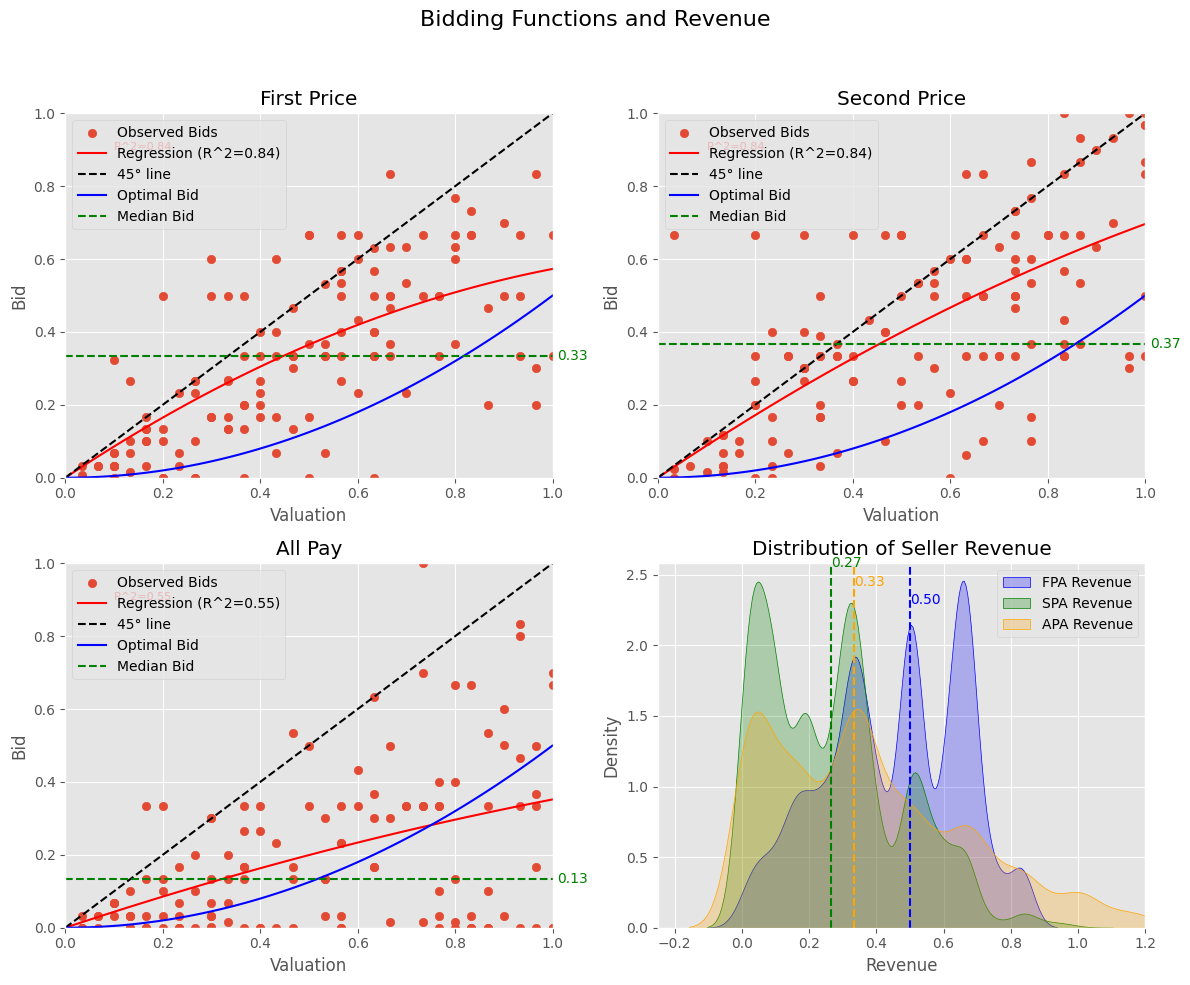

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
plt.style.use('ggplot')
import warnings
warnings.filterwarnings('ignore')

def load_and_clean_data(filepath):
    data = pd.read_csv(filepath)
    # Filter data and remove bids > 100
    filtered_data = data[(data['matched_info'] == 'yes') & (data[['bid_fp', 'bid_sp', 'bid_ap']] <= 100).all(axis=1)].copy()
    return filtered_data

def normalize_data(filtered_data):
    # Normalize data using a uniform min/max of 0 and 30
    val_min = 0
    val_max = 30
    filtered_data[['value_fp', 'value_sp', 'value_ap', 'bid_fp', 'bid_sp', 'bid_ap']] = \
        (filtered_data[['value_fp', 'value_sp', 'value_ap', 'bid_fp', 'bid_sp', 'bid_ap']] - val_min) / (val_max - val_min)
    return filtered_data

def remove_bids_above_one(data):
    return data[(data[['bid_fp', 'bid_sp', 'bid_ap']] <= 1.0).all(axis=1)]

def create_cross_join(data):
    paired_data = data.assign(key=1).merge(data.assign(key=1), on='key').query('name_x != name_y').drop(columns='key')
    paired_data = paired_data[paired_data[['name_x', 'name_y']].apply(frozenset, axis=1).duplicated(keep='first') == False]
    return paired_data

def simulate_auction(df):
    # FPA
    df['fpa_winner'] = np.where(df['bid_fp_x'] > df['bid_fp_y'], df['name_x'], df['name_y'])
    df['fpa_payment'] = np.where(df['bid_fp_x'] > df['bid_fp_y'], df['bid_fp_x'], df['bid_fp_y'])
    df['fpa_winner_valuation'] = np.where(df['fpa_winner'] == df['name_x'], df['value_fp_x'], df['value_fp_y'])
    
    # SPA
    df['spa_winner'] = np.where(df['bid_sp_x'] > df['bid_sp_y'], df['name_x'], df['name_y'])
    df['spa_payment'] = np.where(df['bid_sp_x'] > df['bid_sp_y'], df['bid_sp_y'], df['bid_sp_x'])
    df['spa_winner_valuation'] = np.where(df['spa_winner'] == df['name_x'], df['value_sp_x'], df['value_sp_y'])
    
    # APA
    df['apa_winner'] = np.where(df['bid_ap_x'] > df['bid_ap_y'], df['name_x'], df['name_y'])
    df['apa_payment'] = df['bid_ap_x'] + df['bid_ap_y']
    df['apa_winner_valuation'] = np.where(df['apa_winner'] == df['name_x'], df['value_ap_x'], df['value_ap_y'])

    # Calculate seller revenue and surplus for each format
    df['fpa_surplus'] = df['fpa_winner_valuation'] - df['fpa_payment']
    df['spa_surplus'] = df['spa_winner_valuation'] - df['spa_payment']
    df['apa_surplus'] = df['apa_winner_valuation'] - df['apa_payment']

    return df

def add_regression_line(ax, v, b):
    # Fit a polynomial regression line (v, v^2) without constant
    X = np.column_stack([v, v**2])
    model = sm.OLS(b, X).fit()

    # Generate predicted values
    v_range = np.linspace(0, 1, 100)
    X_pred = np.column_stack([v_range, v_range**2])
    b_pred = model.predict(X_pred)
    
    # Plot regression line and R^2
    ax.plot(v_range, b_pred, color='red', label=f'Regression (R^2={model.rsquared:.2f})')
    ax.text(0.1, 0.9, f'R^2={model.rsquared:.2f}', transform=ax.transAxes, fontsize=8, color='red')

def plot_bids_vs_valuations(data, results):
    plt.figure(figsize=(12, 10))
    plt.suptitle('Bidding Functions and Revenue', fontsize=16)

    # (1) First Price Auction
    plt.subplot(2, 2, 1)
    plt.scatter(data['value_fp'], data['bid_fp'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_fp'], data['bid_fp'])
    plt.plot([0, 1], [0, 1], 'k--', label='45° line')

    # Optimal bidding line
    v_range = np.linspace(0, 1, 100)
    optimal_apa = 0.5 * v_range**2
    plt.plot(v_range, optimal_apa, color='blue', label='Optimal Bid')

    # Median Bid Line and Text
    plt.axhline(data['bid_fp'].median(), color='green', linestyle='--', label='Median Bid')
    plt.text(1.01, data['bid_fp'].median(), f'{data["bid_fp"].median():.2f}', fontsize=10, color='green', ha='left', va='center')

    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title(f'First Price')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    # (2) Second Price Auction
    plt.subplot(2, 2, 2)
    plt.scatter(data['value_sp'], data['bid_sp'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_sp'], data['bid_sp'])
    plt.plot([0, 1], [0, 1], 'k--', label='45° line')
    plt.plot(v_range, optimal_apa, color='blue', label='Optimal Bid')

    # Median Bid Line and Text
    plt.axhline(data['bid_sp'].median(), color='green', linestyle='--', label='Median Bid')
    plt.text(1.01, data['bid_sp'].median(), f'{data["bid_sp"].median():.2f}', fontsize=10, color='green', ha='left', va='center')

    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title(f'Second Price')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    # (3) All Pay Auction
    plt.subplot(2, 2, 3)
    plt.scatter(data['value_ap'], data['bid_ap'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_ap'], data['bid_ap'])
    plt.plot([0, 1], [0, 1], 'k--', label='45° line')
    plt.plot(v_range, optimal_apa, color='blue', label='Optimal Bid')

    # Median Bid Line and Text
    plt.axhline(data['bid_ap'].median(), color='green', linestyle='--', label='Median Bid')
    plt.text(1.01, data['bid_ap'].median(), f'{data["bid_ap"].median():.2f}', fontsize=10, color='green', ha='left', va='center')

    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title(f'All Pay')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    # (4) KDE plot for seller revenue in all three formats with median lines
    plt.subplot(2, 2, 4)
    sns.kdeplot(results['fpa_payment'].dropna(), label='FPA Revenue', shade=True, color='blue')
    sns.kdeplot(results['spa_payment'].dropna(), label='SPA Revenue', shade=True, color='green')
    sns.kdeplot(results['apa_payment'].dropna(), label='APA Revenue', shade=True, color='orange')
    
    # Add vertical lines for medians
    median_fpa = results['fpa_payment'].median()
    median_spa = results['spa_payment'].median()
    median_apa = results['apa_payment'].median()
    
    plt.axvline(median_fpa, color='blue', linestyle='--')
    plt.axvline(median_spa, color='green', linestyle='--')
    plt.axvline(median_apa, color='orange', linestyle='--')
    
    # Annotate median values
    plt.text(median_fpa, plt.ylim()[1]*0.9, f'{median_fpa:.2f}', fontsize=10, color='blue', ha='left', va='center')
    plt.text(median_spa, plt.ylim()[1]*1.0, f'{median_spa:.2f}', fontsize=10, color='green', ha='left', va='center')
    plt.text(median_apa, plt.ylim()[1]*0.95, f'{median_apa:.2f}', fontsize=10, color='orange', ha='left', va='center')

    plt.title(f'Distribution of Seller Revenue')
    plt.xlabel('Revenue')
    plt.ylabel('Density')
    plt.xlim([-0.25, 1.2])
    plt.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# Main flow
filepath = '/home/pp712/double-auctions/code/14_simple/clean_kaplan_data.csv'
filtered_data = load_and_clean_data(filepath)
normalized_data = normalize_data(filtered_data)
normalized_data = remove_bids_above_one(normalized_data)
paired_data = create_cross_join(normalized_data)
results = simulate_auction(paired_data)
plot_bids_vs_valuations(normalized_data, results)

In [1]:
# Separate plotting functions for bidding functions and revenue distributions
def plot_bidding_functions(data):
    plt.figure(figsize=(12, 5))
    plt.suptitle('Bidding Functions', fontsize=16)

    # (1) First Price Auction
    plt.subplot(1, 3, 1)
    plt.scatter(data['value_fp'], data['bid_fp'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_fp'], data['bid_fp'])
    plt.plot([0, 1], [0, 1], 'k--', label='45° line')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title(f'First Price Auction')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    # (2) Second Price Auction
    plt.subplot(1, 3, 2)
    plt.scatter(data['value_sp'], data['bid_sp'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_sp'], data['bid_sp'])
    plt.plot([0, 1], [0, 1], 'k--', label='45° line')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title(f'Second Price Auction')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    # (3) All-Pay Auction
    plt.subplot(1, 3, 3)
    plt.scatter(data['value_ap'], data['bid_ap'], label='Observed Bids')
    add_regression_line(plt.gca(), data['value_ap'], data['bid_ap'])
    plt.plot([0, 1], [0, 1], 'k--', label='45° line')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.title(f'All Pay Auction')
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot revenue distributions
def plot_revenue_distributions(fpa_revenue, spa_revenue, apa_revenue, actual_fpa, actual_spa, actual_apa):
    plt.figure(figsize=(14, 8))
    plt.suptitle('Seller Revenue Distributions', fontsize=16)

    # (1) First Price Auction Revenue Distribution
    plt.subplot(2, 2, 1)
    sns.kdeplot(fpa_revenue, label='Simulated FPA Revenue', shade=True, color='blue')
    sns.kdeplot(actual_fpa, label='Actual FPA Revenue', linestyle='--', color='blue')
    plt.axvline(np.median(fpa_revenue), color='blue', linestyle='--')
    plt.axvline(np.median(actual_fpa), color='blue', linestyle='-')
    plt.title(f'First Price Auction Revenue')
    plt.xlabel('Revenue')
    plt.ylabel('Density')
    plt.legend()

    # (2) Second Price Auction Revenue Distribution
    plt.subplot(2, 2, 2)
    sns.kdeplot(spa_revenue, label='Simulated SPA Revenue', shade=True, color='green')
    sns.kdeplot(actual_spa, label='Actual SPA Revenue', linestyle='--', color='green')
    plt.axvline(np.median(spa_revenue), color='green', linestyle='--')
    plt.axvline(np.median(actual_spa), color='green', linestyle='-')
    plt.title(f'Second Price Auction Revenue')
    plt.xlabel('Revenue')
    plt.ylabel('Density')
    plt.legend()

    # (3) All-Pay Auction Revenue Distribution
    plt.subplot(2, 2, 3)
    sns.kdeplot(apa_revenue, label='Simulated APA Revenue', shade=True, color='orange')
    sns.kdeplot(actual_apa, label='Actual APA Revenue', linestyle='--', color='orange')
    plt.axvline(np.median(apa_revenue), color='orange', linestyle='--')
    plt.axvline(np.median(actual_apa), color='orange', linestyle='-')
    plt.title(f'All-Pay Auction Revenue')
    plt.xlabel('Revenue')
    plt.ylabel('Density')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Main flow
filepath = 'clean_kaplan_data.csv'
filtered_data = load_and_clean_data(filepath)
normalized_data = normalize_data(filtered_data)

# Extract actual revenue distributions from true bids
actual_fpa, actual_spa, actual_apa = extract_actual_revenue_distribution(normalized_data)

# Fitting KDE for first price valuation distribution
kde_fp = gaussian_kde(normalized_data['value_fp'].values)

# Interpolation function for SPA
spa_bidding_func = lambda v: np.interp(v, np.linspace(0, 1, len(learned_bidding_function_spa)), learned_bidding_function_spa)

# Interpolation function for APA
apa_bidding_func = lambda v: np.interp(v, np.linspace(0, 1, len(learned_bidding_function_apa)), learned_bidding_function_apa)

# Simulating seller revenues for each auction type
fpa_revenue = simulate_revenue_distribution(kde_fp, lambda v: 0.61 * v, 'FPA')  # Example FPA bidding function
spa_revenue = simulate_revenue_distribution(kde_fp, spa_bidding_func, 'SPA')
apa_revenue = simulate_revenue_distribution(kde_fp, apa_bidding_func, 'APA')

# Plot the bidding functions
plot_bidding_functions(normalized_data)

# Plot the revenue distributions
plot_revenue_distributions(fpa_revenue, spa_revenue, apa_revenue, actual_fpa, actual_spa, actual_apa)


NameError: name 'load_and_clean_data' is not defined